## Reading in Datasets from Kaggle
#### Given the total size of the entire Kaggle Dataset (89GB) capturing 153M QUIC protocol flows *weeks_to_download* variable lets you select which weeks to download

In [1]:
import math

from tensorflow.python.autograph.pyct.templates import replace

from data_acquisition import Data_acquisition

da = Data_acquisition()

# Specify which weeks to be downloaded
weeks_to_download = ['week_1', 'week_2', 'week_3', 'week_4']

da.download_datasets(weeks_to_download)

Downloading: cesnet-quic22/W-2022-44/1_Mon/flows-20221031.csv


100%|██████████| 2.03G/2.03G [01:32<00:00, 23.6MB/s]


Downloading: cesnet-quic22/W-2022-45/1_Mon/flows-20221107.csv


100%|██████████| 4.58G/4.58G [02:37<00:00, 31.3MB/s]


Downloading: cesnet-quic22/W-2022-46/1_Mon/flows-20221114.csv


100%|██████████| 4.54G/4.54G [03:10<00:00, 25.7MB/s]


Downloading: cesnet-quic22/W-2022-47/1_Mon/flows-20221121.csv


100%|██████████| 4.68G/4.68G [02:58<00:00, 28.2MB/s]

Download complete at for 4 weeks in ./dataset


In [2]:
import pandas as pd
import numpy as np

### Data Exploration
#### Given the size only one day of data is explored to examine features and their distributions

In [3]:
week1_mon_df = pd.read_csv('./dataset/week_1/mon.csv')
week1_mon_df.head(5)

,ID,SRC_IP,DST_IP,DST_ASN,SRC_PORT,DST_PORT,PROTOCOL,QUIC_VERSION,QUIC_SNI,QUIC_USERAGENT,...,APP,CATEGORY,FLOW_ENDREASON_IDLE,FLOW_ENDREASON_ACTIVE,FLOW_ENDREASON_OTHER,PPI,PHIST_SRC_SIZES,PHIST_DST_SIZES,PHIST_SRC_IPT,PHIST_DST_IPT
0,0,156.248.83.16,162.159.135.232,13335,63519,443,17,4278190109,status.discord.com,NaN,...,discord,Instant messaging,True,False,False,"[[0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 7, 0, 0, 0, 0,...","[0, 0, 5, 2, 0, 1, 0, 3]","[0, 3, 1, 1, 0, 0, 1, 2]","[9, 1, 0, 0, 0, 0, 0, 0]","[7, 0, 0, 0, 0, 0, 0, 0]"
1,1,114.175.67.49,31.13.70.52,32934,6194,443,17,4207849474,i.instagram.com,NaN,...,instagram,Social,True,False,False,"[[0, 100, 64, 0, 0, 0, 0, 8, 0, 0, 3, 0, 33, 5...","[0, 0, 94, 5, 4, 8, 20, 18]","[0, 0, 71, 4, 7, 19, 19, 178]","[73, 23, 24, 15, 7, 2, 3, 1]","[219, 26, 24, 13, 8, 3, 3, 1]"
2,2,156.248.89.205,157.240.30.18,32934,60727,443,17,4207849474,graph.facebook.com,NaN,...,facebook-graph,Other services and APIs,True,False,False,"[[0, 2, 0, 0, 8, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 2, 1, 0, 0, 1, 24]","[0, 0, 5, 2, 1, 1, 1, 1]","[26, 0, 1, 0, 0, 0, 0, 0]","[7, 3, 0, 0, 0, 0, 0, 0]"
3,3,2042:fcc7:e182:eead:4dce:4d2b:934:ebaa,2a03:2880:f03d:1c:face:b00c:0:3,32934,57700,443,17,1,scontent-prg1-1.xx.fbcdn.net,NaN,...,facebook-media,Streaming media,True,False,False,"[[0, 0, 0, 3, 0, 0, 0, 0, 1, 0, 29, 0, 0, 0, 1...","[0, 0, 4, 2, 0, 0, 1, 2]","[0, 0, 3, 2, 1, 2, 0, 2]","[6, 1, 1, 0, 0, 0, 0, 0]","[8, 1, 0, 0, 0, 0, 0, 0]"
4,4,2042:fcc7:e183:6e69:62da:a058:5538:c3cb,2a03:2880:f23d:c6:face:b00c:0:43fe,32934,65171,443,17,4207849474,i.instagram.com,NaN,...,instagram,Social,True,False,False,"[[0, 3, 0, 0, 9, 1, 0, 0, 0, 0, 2, 4, 63, 0, 1...","[0, 0, 38, 2, 4, 3, 4, 34]","[0, 0, 36, 4, 8, 5, 14, 74]","[47, 14, 6, 6, 2, 2, 3, 4]","[103, 11, 6, 9, 2, 3, 2, 4]"


In [4]:
week1_mon_df.info()
week1_mon_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3576486 entries, 0 to 3576485
Data columns (total 30 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     int64  
 1   SRC_IP                 str    
 2   DST_IP                 str    
 3   DST_ASN                int64  
 4   SRC_PORT               int64  
 5   DST_PORT               int64  
 6   PROTOCOL               int64  
 7   QUIC_VERSION           int64  
 8   QUIC_SNI               str    
 9   QUIC_USERAGENT         str    
 10  TIME_FIRST             str    
 11  TIME_LAST              str    
 12  DURATION               float64
 13  BYTES                  int64  
 14  BYTES_REV              int64  
 15  PACKETS                int64  
 16  PACKETS_REV            int64  
 17  PPI_LEN                int64  
 18  PPI_DURATION           float64
 19  PPI_ROUNDTRIPS         int64  
 20  APP                    str    
 21  CATEGORY               str    
 22  FLOW_ENDREASON_IDLE    bool  

ID                             0
SRC_IP                         0
DST_IP                         0
DST_ASN                        0
SRC_PORT                       0
DST_PORT                       0
PROTOCOL                       0
QUIC_VERSION                   0
QUIC_SNI                       0
QUIC_USERAGENT           3568380
TIME_FIRST                     0
TIME_LAST                      0
DURATION                       0
BYTES                          0
BYTES_REV                      0
PACKETS                        0
PACKETS_REV                    0
PPI_LEN                        0
PPI_DURATION                   0
PPI_ROUNDTRIPS                 0
APP                            0
CATEGORY                       0
FLOW_ENDREASON_IDLE            0
FLOW_ENDREASON_ACTIVE          0
FLOW_ENDREASON_OTHER           0
PPI                            0
PHIST_SRC_SIZES                0
PHIST_DST_SIZES                0
PHIST_SRC_IPT                  0
PHIST_DST_IPT                  0
dtype: int

#### Class Distribution

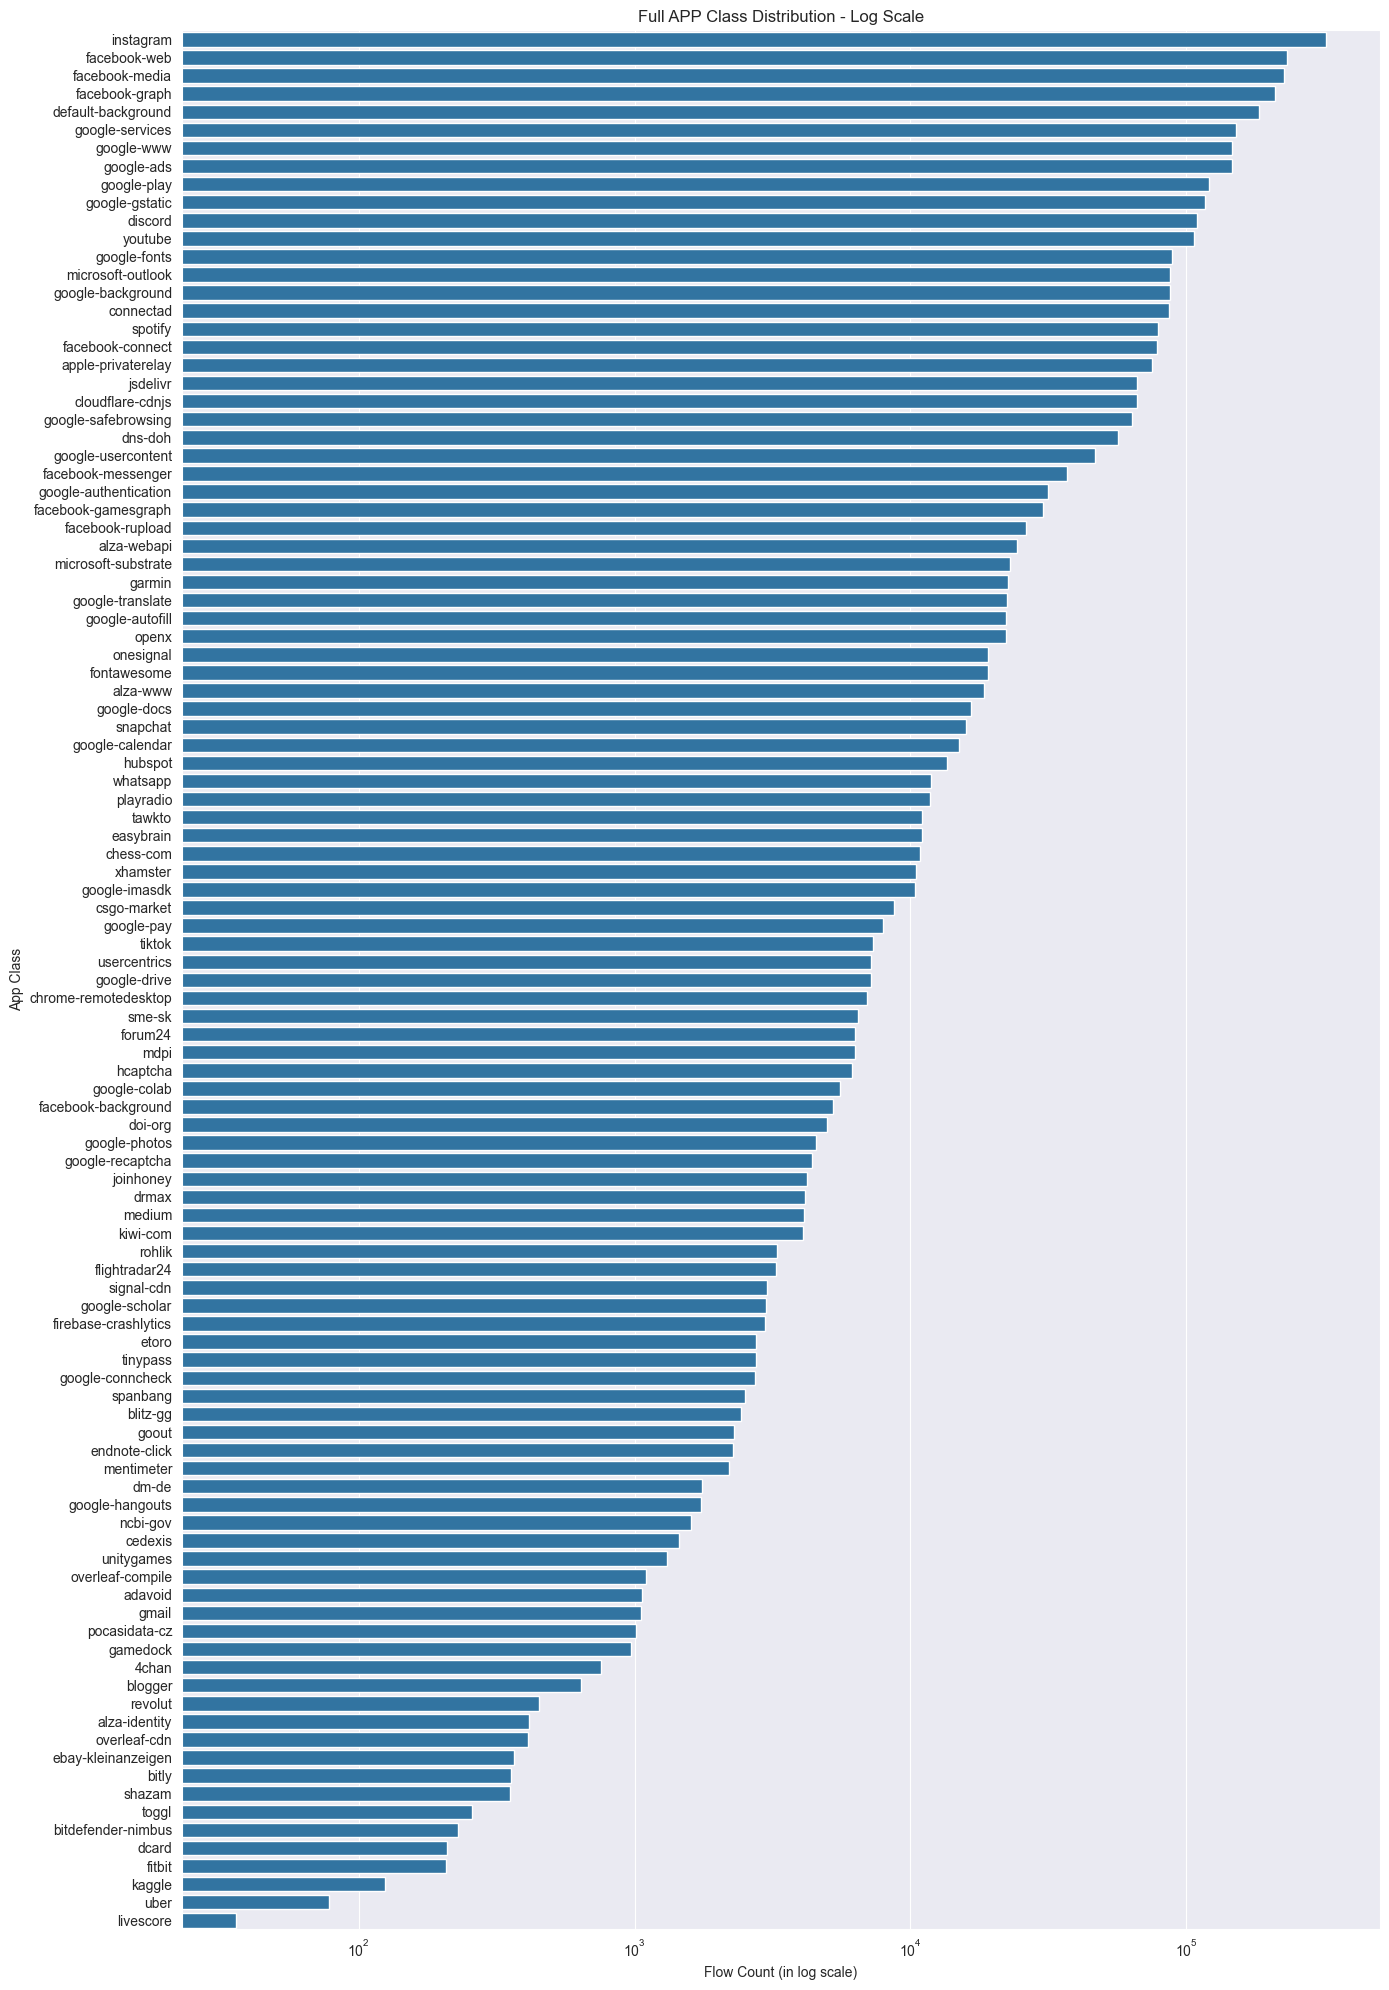

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

app_counts = week1_mon_df['APP'].value_counts()


plt.figure(figsize=(14, 20))
sns.barplot(x=app_counts.values, y=app_counts.index)
plt.xscale('log')
plt.xlabel('Flow Count (in log scale)')
plt.ylabel('App Class')
plt.title('Full APP Class Distribution - Log Scale')
plt.tight_layout()
plt.show()

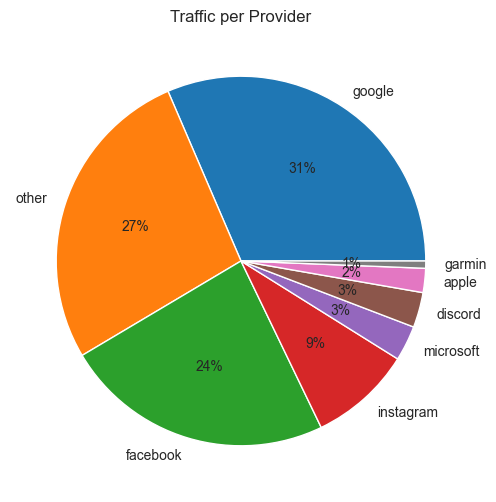

In [6]:
providers = ['google', 'microsoft', 'facebook','discord', 'instagram', 'apple', 'garmin']
def get_provider(app_name):
    app_lower = str(app_name).lower()
    for provider in providers:
        if provider in app_lower:
            return provider
    return 'other'

app_provider_percentage = (
    app_counts
    .groupby(get_provider)
    .sum()
    .pipe(lambda s: s / s.sum() * 100)
    .round(2)
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 6))
plt.pie(app_provider_percentage, labels=app_provider_percentage.index, autopct='%1.0f%%')
plt.title('Traffic per Provider')
plt.show()

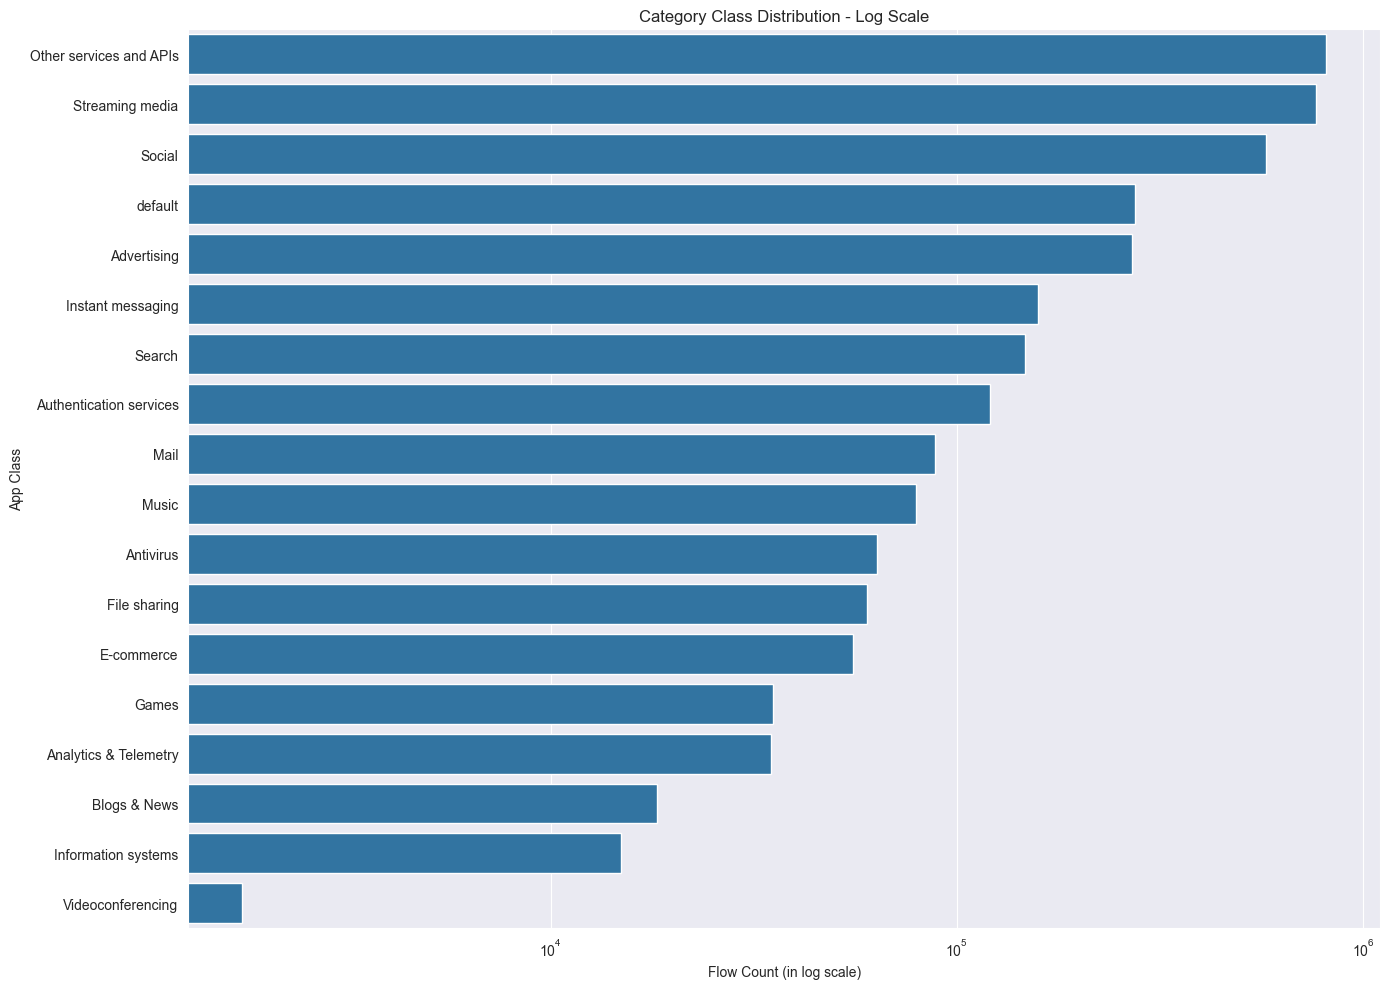

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

category_counts = week1_mon_df['CATEGORY'].value_counts()


plt.figure(figsize=(14, 10))
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.xscale('log')
plt.xlabel('Flow Count (in log scale)')
plt.ylabel('App Class')
plt.title('Category Class Distribution - Log Scale')
plt.tight_layout()
plt.show()

### Dropping Useless Columns prior to Storing in Database to reduce dataset size
#### Cols Dropped and Rational:
##### ID: Identifier column, no predictable signal.
##### SRC_IP/DST_IP: Dropped since although still present post ECH, vary across CDN's and load balancers. Model would memorise IP addresses rather.
##### DST_ASN: Derived from DST_IP and hence is proxy introducing data-leakage.
##### DST_PORT: Consistent, (443) is standard for QUIC.
##### PROTOCOL: Consistent all flows are QUIC-over-UDP.
##### QUIC_VERSION: Extracted from HelloClient Handshake.
##### QUIC_SNI: Extracted from HelloClient Handshake.
##### QUIC_USERAGENT: Derrived from HelloClient Handshake and lots of nulls.
###
#### Cols used for labels
##### APP: Application used (Fine-grained Label)
##### CATEGORY: Type of traffic (Generic Label)

In [8]:
# Drops columns and converts and replaces .csv files with .parquet to increase efficiency and decrease storage requirements
import json

cols_to_drop = []

cols_to_drop= ['ID', 'SRC_IP', 'DST_IP', 'DST_ASN', 'SRC_PORT', 'DST_PORT', 'PROTOCOL', 'QUIC_VERSION', 'QUIC_SNI', 'QUIC_USERAGENT']
with open('./config.json', 'w') as f:
    json.dump({'cols_to_drop': cols_to_drop}, f, indent=4)

# Ran as script due to multiprocessing
!python preprocessing.py

Done: ./dataset\week_1\mon.parquet
Done: ./dataset\week_3\mon.parquet
Done: ./dataset\week_2\mon.parquet
Done: ./dataset\week_4\mon.parquet


### Extracting nested data
##### PPI column contains three nested arrays per row (PPI_TIMES, PPI_DIRS, PPI_SIZES) consisting indices presenting 30 packets each. these are parsed and extracted into individual dataframe features.
##### PHIST columns (PHIST_SRC_SIZES etc...) have a single array per row consisting of 8 histogram bin counts. Each bin represents the number of packets falling within a specific size or inter-packet time range (on a log scale). These are parsed and extracted into individual dataframe features.

In [3]:
import pandas as pd
from feature_engineering import Feature_Engineering

ppi_pad_len = 30
phist_pad_len = 8

def pipeline_parse_cols(fe: Feature_Engineering, df: pd.DataFrame, ppi_pad_len: int, phist_pad_len: int):
    print('Parsing PPI cols')
    fe.parse_col('PPI', ['PPI_TIMES', 'PPI_DIRS', 'PPI_SIZES'])
    fe.parse_col_lists(ppi_pad_len)
    print('Parsing PHIST cols')
    fe.parse_col('PHIST_SRC_SIZES', ['PHIST_SRC_SIZES'])
    fe.parse_col('PHIST_DST_SIZES', ['PHIST_DST_SIZES'])
    fe.parse_col('PHIST_SRC_IPT', ['PHIST_SRC_IPT'])
    fe.parse_col('PHIST_DST_IPT', ['PHIST_DST_IPT'])
    fe.parse_col_lists(phist_pad_len)


#### Encoding and Scalings:
##### Data Exploration below reveals that numerical features are heavily skewed to the right indicating massive outlier ranges, therefore all numerical features were scaled using RobustScaler in order to not destroy these outliers

##### Label features were encoded using label encoder over one hot encoding given the number of additional columns that would need to be created. Dataframes are already massive with lots of features, adding more increases overfitting risk aswell as increased computation during model training.

In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

sample_day = pd.read_parquet('./dataset/week_1/mon.parquet')

ppi_sample_packet = math.floor(ppi_pad_len/3)
phist_sample_packet = math.floor(phist_pad_len/3)

numerical_cols = ['DURATION', 'BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV', 'PPI_LEN', 'PPI_DURATION', 'PPI_ROUNDTRIPS', f'PPI_TIMES_{ppi_sample_packet}', f'PPI_DIRS_{ppi_sample_packet}', f'PPI_SIZES_{ppi_sample_packet}', f'PHIST_SRC_SIZES_{phist_sample_packet}', f'PHIST_DST_SIZES_{phist_sample_packet}', f'PHIST_SRC_IPT_{phist_sample_packet}', f'PHIST_DST_IPT_{phist_sample_packet}']

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 12))
axes = axes.flatten()  # now just a flat list of 15 slots

for i, col in enumerate(numerical_cols):
    sns.histplot(sample_day[col], kde=False, log_scale=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

NameError: name 'ppi_pad_len' is not defined

In [2]:
import pandas as pd
df = pd.read_parquet('./dataset/week_1/mon.parquet')
df = df.head(5000)
df.to_parquet('./dataset/week_1/mon.parquet')

##### Ostrates the scaling and encoding of each days dataset and saves them to ./tabular_dataset and ./sequential_dataset for ML models to use.

##### - tabular datasets contain all features + labels with PPI and PHIST array indices split into individual columns

##### - sequential datasets contain only PPI's + labels with each PPI as an array

In [4]:
from sklearn.preprocessing import LabelEncoder, RobustScaler
import write_out
import pandas as pd
import os

# Storing scaler and encoders for reverse_transform after
le = LabelEncoder()
re = RobustScaler()
encoders_dict = {'label_encoder': le,
                 'RobustScaler': re}

for week in sorted(os.listdir('./dataset')):
    week_path = os.path.join('./dataset', week)
    if os.path.isdir(week_path):
        for file in sorted(os.listdir(week_path)):
            if file.endswith('.parquet'):
                file_path = os.path.join(week_path, file)
                df = pd.read_parquet(file_path)
                print(f'{week}/{file}: {df.shape}')

                # Samples 1000 of each 'APP' class and uses tiered sampling for classes < max_samples to where rows are duplicated once > min_samples.
                fe.tier_sampling(max_samples=1000, min_samples=50)
                pipeline_parse_cols(fe, df, ppi_pad_len, phist_pad_len)

                fe.perform_encode_and_scaling(encoders_dict)

                tabular_df = fe.get_tabular_dataset()
                write_out.write_out_tabular(tabular_df, week, file)

                sequential_df = fe.get_ppi_sequential_only()
                write_out.write_out_sequential(sequential_df, week, file)


week_1/mon.parquet: (3576486, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust Scaling...
Merging final df
TABULAR_DATASET_PATH: ./tabular_dataset/tabular_week_1_mon.parquet
tabular_week_1_mon.parquet: (104000, 135) saved to ./tabular_dataset/tabular_week_1_mon.parquet
TABULAR_DATASET_PATH: ./sequential_dataset/sequential_week_1_mon.parquet
sequential_week_1_mon.parquet: (104000, 92) saved to ./sequential_dataset/sequential_week_1_mon.parquet
week_2/mon.parquet: (8118835, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust Scaling...
Merging final df
TABULAR_DATASET_PATH: ./tabular_dataset/tabular_week_2_mon.parquet
tabular_week_2_mon.parquet: (105000, 135) saved to ./tabular_dataset/tabular_week_2_mon.parquet
TABULAR_DATASET_PATH: ./sequential_dataset/sequential_week_2_mon.parquet
sequential_week_2_mon.parquet: (105000, 92) saved to ./sequential_dataset/sequential_week_2_mon.parquet
week_3/mon.parquet: (8046282, 20)
Parsing PPI cols
Parsing PHIST cols
Labe

#### Combining days of sequential and tabular dataset's so that they can be used for model testing and training

In [12]:
def concat_days_together(file_path) -> pd.DataFrame:
    to_combine = []
    for file in sorted(os.listdir(file_path)):
        if file.endswith('.parquet'):
            df_of_day = pd.read_parquet(os.path.join(file_path, file))
            to_combine.append(df_of_day)
    return pd.concat(to_combine, ignore_index=True)

tabular_df = concat_days_together('./tabular_dataset')

sequential_df = concat_days_together('./sequential_dataset')

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

y = tabular_df['APP']
X = tabular_df.drop(columns=['APP', 'CATEGORY'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [20]:
from sklearn.metrics import f1_score, classification_report

# Macro F1 — your primary metric
f1 = f1_score(y_test, y_pred, average='macro')
print(f'Macro F1: {f1:.4f}')

# Full breakdown per class
print(classification_report(y_test, y_pred, zero_division=0))

Macro F1: 0.7987
              precision    recall  f1-score   support

           0       0.73      0.82      0.77      1200
           1       0.82      0.92      0.87      1200
           2       0.87      0.91      0.89      1200
           3       0.80      0.81      0.81      1200
           4       0.61      0.67      0.63      1200
           5       0.99      1.00      1.00      1200
           6       0.94      0.98      0.96      1200
           7       0.91      0.92      0.92      1200
           8       0.83      0.81      0.82      1200
           9       0.74      0.82      0.78      1200
          10       0.90      0.89      0.90      1200
          11       0.61      0.43      0.50      1200
          12       0.94      0.97      0.96      1200
          13       0.55      0.64      0.59      1200
          14       0.70      0.82      0.76      1200
          15       0.97      0.99      0.98      1200
          16       0.90      0.99      0.94      1200
          